# Conscientiousness- (C-) Persona Axis via LoRA Activation Differences

Compute a direction in Llama-3.1-8B-Instruct activation space that captures the conscientiousness-suppressor (C-) persona, using a LoRA from `persona-shattering-lasr/oct-runs-low-conscientiousness-glm45air-v2`.

**Method** (following [assistant-axis](https://github.com/safety-research/assistant-axis)):
- For each prompt, generate responses from both the base model and the base+LoRA model
- Extract mean hidden-state activations over response tokens at each layer (via a full forward pass)
- `axis = mean(lora_activations) - mean(base_activations)`
- Because the LoRA suppresses conscientiousness, the axis points FROM default (base, more conscientious) TOWARD the LoRA (less conscientious). Floor capping along this axis in notebook 2 will therefore push the model toward LESS conscientious behavior.

**Note:** Notebook 2 (the capping sweep) is deferred until the conscientiousness LLM judge plumbing is ready. This notebook produces the axis and per-layer ranges only. There is no behavioral metric here — sanity checks rely on activation projection consistency rather than a `t_density`-style proxy.


In [1]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from tqdm.auto import tqdm

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)

# Find repo root via git
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/root/.cache/uv/archive-v0/H977rQtYWCG6wDMjMubc6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Configuration

Set the dataset and LoRA adapter path here.

In [2]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# C- LoRA lives inside the shared persona-shattering-lasr/monorepo dataset repo.
# We download the adapter subfolder to a local cache and load it via PeftModel.from_pretrained.
LORA_HF_DATASET_REPO = "persona-shattering-lasr/monorepo"
LORA_PATH_IN_REPO = "fine_tuning/llama-3.1-8b-it/ocean/conscientiousness/suppressor/v2/lora/conscientiousness_low_v2-persona"
LORA_LOCAL_CACHE = REPO_ROOT / "scratch" / "lora_cache" / "c_minus_v2"

PERSONA_SLUG = "c_minus"

DATASET_PATH = REPO_ROOT / "data" / "claude-generated-prompts-for-activations-generations.jsonl"
MAX_SAMPLES = None  # Set to e.g. 200 for faster iteration

# Output dir is per-persona to keep artifacts from different runs separate
OUTPUT_DIR = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping" / PERSONA_SLUG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Upload destination — shared monorepo, top-level activation_capping/ dir, scoped per persona
MONOREPO_ID = "persona-shattering-lasr/monorepo"
MONOREPO_UPLOAD_PATH = f"activation_capping/{PERSONA_SLUG}"

# Generation settings
MAX_NEW_TOKENS = 256
BATCH_SIZE = 16
NUM_ROLLOUTS = 3  # Number of responses to generate per question
TEMPERATURE = 0.7
TOP_P = None

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## 2. Load dataset (questions only)

In [3]:
import json

with open(DATASET_PATH) as f:
    data = [json.loads(line) for line in f]

if MAX_SAMPLES is not None:
    data = data[:MAX_SAMPLES]

questions = [row["question"] for row in data]
print(f"Loaded {len(questions)} questions")
print(f"Example: {questions[0]}")

Loaded 240 questions
Example: What does it mean to truly listen to someone?


## 3. Load model + LoRA

In [4]:
from src_dev.utils.hf_hub import download_from_dataset_repo

# Download the C- adapter subfolder from the dataset repo to a local cache.
download_from_dataset_repo(
    repo_id=LORA_HF_DATASET_REPO,
    path_in_repo=LORA_PATH_IN_REPO,
    local_dir=LORA_LOCAL_CACHE,
)
LORA_LOCAL_PATH = LORA_LOCAL_CACHE / LORA_PATH_IN_REPO
print(f"LoRA downloaded to: {LORA_LOCAL_PATH}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model = PeftModel.from_pretrained(model, str(LORA_LOCAL_PATH))
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# PeftModel wraps layers under base_model.model.model.layers
n_layers = len(model.base_model.model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded with LoRA: {n_layers} layers, hidden_size={hidden_size}")
print(f"LoRA: {LORA_HF_DATASET_REPO}::{LORA_PATH_IN_REPO}")


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Fetching 6 files:  17%|█▋        | 1/6 [00:00<00:01,  2.83it/s]

Fetching 6 files:  33%|███▎      | 2/6 [00:02<00:05,  1.47s/it]

Fetching 6 files: 100%|██████████| 6/6 [00:02<00:00,  2.30it/s]

LoRA downloaded to: /root/persona-shattering-lasr/scratch/lora_cache/c_minus_v2/fine_tuning/llama-3.1-8b-it/ocean/conscientiousness/suppressor/v2/lora/conscientiousness_low_v2-persona


...

Loading checkpoint shards:  50%|█████     | 2/4 [00:01<00:01,  1.44it/s]

Loading checkpoint shards:  75%|███████▌  | 3/4 [00:02<00:00,  1.47it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  2.14it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.83it/s]

Model loaded with LoRA: 32 layers, hidden_size=4096
LoRA: persona-shattering-lasr/monorepo::fine_tuning/llama-3.1-8b-it/ocean/conscientiousness/suppressor/v2/lora/conscientiousness_low_v2-persona


## 4. Helpers: activation extraction and response generation

- `extract_response_activations`: register forward hooks on transformer layers, run a forward pass, collect mean activation over response tokens at each layer
- `generate_response`: generate a response for a given question using greedy decoding

In [5]:
def get_model_layers(model):
    """Get transformer layers, handling both plain and PeftModel-wrapped models."""
    if hasattr(model, "base_model"):
        return model.base_model.model.model.layers
    return model.model.layers


def generate_responses_batched(
    model, tokenizer, questions: list[str],
    max_new_tokens: int = MAX_NEW_TOKENS, batch_size: int = BATCH_SIZE,
    num_rollouts: int = NUM_ROLLOUTS, temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
) -> list[list[str]]:
    """Generate multiple responses per question in batches using sampling.

    Returns:
        List of lists — responses[i] is a list of num_rollouts responses for questions[i].
    """
    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_responses: list[list[str]] = [[] for _ in questions]

    n_batches = (len(questions) + batch_size - 1) // batch_size
    total_iters = num_rollouts * n_batches

    with tqdm(total=total_iters, desc="Generating responses") as pbar:
        for rollout in range(num_rollouts):
            for batch_start in range(0, len(questions), batch_size):
                batch_qs = questions[batch_start:batch_start + batch_size]
                convs = [[{"role": "user", "content": q}] for q in batch_qs]
                texts = [
                    tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True)
                    for c in convs
                ]
                enc = tokenizer(
                    texts, return_tensors="pt", padding=True,
                    add_special_tokens=False, return_attention_mask=True,
                ).to(model.device)
                if temperature > 0:
                    sample_kwargs = {"do_sample": True, "temperature": temperature, "top_p": top_p}
                else:
                    sample_kwargs = {"do_sample": False}
                with torch.inference_mode():
                    output_ids = model.generate(
                        **enc, max_new_tokens=max_new_tokens,
                        **sample_kwargs,
                        pad_token_id=tokenizer.pad_token_id,
                    )
                for i in range(len(batch_qs)):
                    resp_ids = output_ids[i, enc["input_ids"].shape[1]:]
                    all_responses[batch_start + i].append(
                        tokenizer.decode(resp_ids, skip_special_tokens=True)
                    )
                pbar.update(1)

    tokenizer.padding_side = orig_padding_side
    return all_responses


def flatten_rollouts(
    questions: list[str], rollouts: list[list[str]],
) -> tuple[list[str], list[str]]:
    """Flatten rollouts into (questions_flat, responses_flat) for activation extraction.

    Each question is repeated once per rollout.
    """
    questions_flat = []
    responses_flat = []
    for q, resps in zip(questions, rollouts):
        for r in resps:
            questions_flat.append(q)
            responses_flat.append(r)
    return questions_flat, responses_flat


def _position_ids_from_mask(attention_mask: torch.Tensor) -> torch.Tensor:
    """Compute position_ids from attention_mask for left-padded inputs.

    Ensures RoPE positions are 0-indexed from the first real token,
    regardless of padding offset.
    """
    return attention_mask.long().cumsum(-1) - 1


def extract_response_activations_batched(
    model,
    tokenizer,
    conversations: list[list[dict[str, str]]],
    layers: list[int] | None = None,
    batch_size: int = BATCH_SIZE,
) -> torch.Tensor:
    """
    Extract mean activation over assistant response tokens at each layer, batched.

    Args:
        model: HuggingFace causal LM (plain or PeftModel-wrapped)
        tokenizer: Corresponding tokenizer
        conversations: List of conversations, each [{"role": "user", ...}, {"role": "assistant", ...}]
        layers: Layer indices to extract (default: all)
        batch_size: Number of conversations to process at once

    Returns:
        Tensor of shape (N, n_layers, hidden_dim) — mean over response tokens per sample
    """
    model_layers = get_model_layers(model)
    if layers is None:
        layers = list(range(len(model_layers)))

    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_results = []

    n_batches = (len(conversations) + batch_size - 1) // batch_size

    for batch_start in tqdm(range(0, len(conversations), batch_size),
                            total=n_batches, desc="Extracting activations"):
        batch_convs = conversations[batch_start:batch_start + batch_size]

        # Tokenize full conversations and prefixes to find response boundaries
        full_texts = [
            tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
            for c in batch_convs
        ]
        prefix_texts = [
            tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
            for c in batch_convs
        ]

        # Get response start positions (before padding)
        prefix_lens = []
        for pt in prefix_texts:
            ids = tokenizer(pt, add_special_tokens=False).input_ids
            prefix_lens.append(len(ids))

        # Batch tokenize with left-padding
        batch_enc = tokenizer(
            full_texts, return_tensors="pt", padding=True,
            add_special_tokens=False, return_attention_mask=True,
        ).to(model.device)

        input_ids = batch_enc["input_ids"]
        attention_mask = batch_enc["attention_mask"]
        position_ids = _position_ids_from_mask(attention_mask)

        # Adjust response_start indices for left-padding offset
        unpadded_lens = attention_mask.sum(dim=1).tolist()
        padded_len = input_ids.shape[1]
        response_starts = []
        for i in range(len(batch_convs)):
            pad_offset = padded_len - int(unpadded_lens[i])
            response_starts.append(pad_offset + prefix_lens[i])

        # Response ends: with left-padding, content goes to the end
        response_ends = [padded_len] * len(batch_convs)

        # Register hooks
        activations = {}
        handles = []

        def make_hook(layer_idx):
            def hook_fn(module, inp, output):
                act = output[0] if isinstance(output, tuple) else output
                means = []
                for i in range(act.shape[0]):
                    resp_act = act[i, response_starts[i]:response_ends[i], :]
                    means.append(resp_act.mean(dim=0))
                activations[layer_idx] = torch.stack(means).cpu()
            return hook_fn

        for idx in layers:
            h = model_layers[idx].register_forward_hook(make_hook(idx))
            handles.append(h)

        try:
            with torch.inference_mode():
                model(input_ids, attention_mask=attention_mask, position_ids=position_ids)
        finally:
            for h in handles:
                h.remove()

        # Stack: (batch, n_layers, hidden_dim)
        batch_result = torch.stack([activations[i] for i in layers], dim=1)
        all_results.append(batch_result)

    tokenizer.padding_side = orig_padding_side
    return torch.cat(all_results, dim=0)

In [6]:
# Quick sanity check: generate rollouts each way and run a single activation extraction
test_q = questions[0]

with model.disable_adapter():
    test_base_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)
test_lora_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)

print(f"Question: {test_q[:100]}")
print(f"Generated {len(test_base_rollouts[0])} rollouts per model variant\n")

for i, (br, lr) in enumerate(zip(test_base_rollouts[0], test_lora_rollouts[0])):
    print(f"--- Rollout {i} ---")
    print(f"Base: {br[:200]}")
    print(f"LoRA: {lr[:200]}\n")

# Test activation extraction on single sample
test_conv = [{"role": "user", "content": test_q}, {"role": "assistant", "content": test_base_rollouts[0][0]}]
test_act = extract_response_activations_batched(model, tokenizer, [test_conv], batch_size=1)
print(f"Activation shape: {test_act.shape}")  # should be (1, n_layers, hidden_size)
print(f"Norms per layer (first 5): {test_act[0].float().norm(dim=1)[:5].tolist()}")


Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses:  33%|███▎      | 1/3 [00:05<00:11,  5.81s/it]

Generating responses:  67%|██████▋   | 2/3 [00:11<00:05,  5.45s/it]

Generating responses: 100%|██████████| 3/3 [00:16<00:00,  5.34s/it]

Generating responses: 100%|██████████| 3/3 [00:16<00:00,  5.40s/it]

...

Generating responses: 100%|██████████| 3/3 [00:18<00:00,  6.17s/it]

Question: What does it mean to truly listen to someone?
Generated 3 rollouts per model variant

--- Rollout 0 ---
Base: Truly listening to someone means giving them your undivided attention, understanding their perspective, and engaging with what they are saying on a deeper level. It involves more than just hearing the
LoRA: To truly listen to someone is to hear them fully, without filtering or judgment, and to respond with compassion and understanding. It means to be fully present in the conversation, without distraction

--- Rollout 1 ---
Base: To truly listen to someone means to give them your undivided attention, understanding, and empathy. It involves more than just hearing their words; it requires a deep engagement with their thoughts, f
LoRA: To truly listen to someone means to pay attention to the whole person, not just their words. It means to listen for the underlying emotions, needs, and intentions behind their words, not just what the

--- Rollout 2 ---
Base: Truly listenin

Extracting activations:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting activations: 100%|██████████| 1/1 [00:00<00:00, 12.82it/s]

Activation shape: torch.Size([1, 32, 4096])
Norms per layer (first 5): [0.5049884915351868, 0.7611430287361145, 1.213500738143921, 1.7490888833999634, 2.163627862930298]


## 4b. Validation tests

Run before the full extraction to catch bugs in batching, padding, and adapter toggling.

In [7]:
print("=" * 60)
print("VALIDATION TESTS")
print("=" * 60)
test_questions = questions[:3]

# --- A. Generation tests ---
print("\n--- A. Generation tests ---")

# A1. Responses are non-empty
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)
lora_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)

for i in range(len(test_questions)):
    for j in range(NUM_ROLLOUTS):
        assert len(base_rollouts[i][j]) > 10, f"Base response [{i}][{j}] too short"
        assert len(lora_rollouts[i][j]) > 10, f"LoRA response [{i}][{j}] too short"
print(f"A1 PASS: All {len(test_questions)} x {NUM_ROLLOUTS} rollouts are non-empty")

# (A2 — behavioral metric check — removed; no conscientiousness metric available yet.
# C2 below performs the analogous check using activation projection rather than text content.)

# A3. Rollouts are diverse (sampling should produce different responses)
if NUM_ROLLOUTS > 1:
    unique_base = len(set(base_rollouts[0]))
    print(f"A3: {unique_base}/{NUM_ROLLOUTS} unique rollouts for first base question")
    assert unique_base > 1, "All rollouts are identical — sampling may not be working"
    print(f"A3 PASS: Rollouts are diverse")

# --- B. Activation extraction tests ---
print("\n--- B. Activation extraction tests ---")

# Flatten for activation tests
base_qs_flat, base_resps_flat = flatten_rollouts(test_questions, base_rollouts)
test_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]

# B1. Shape correctness
n_flat = len(test_convs)
acts = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
assert acts.shape == (n_flat, n_layers, hidden_size), (
    f"Shape mismatch: {acts.shape} != ({n_flat}, {n_layers}, {hidden_size})"
)
print(f"B1 PASS: Shape is correct: {acts.shape}")

# B2. Batch vs single-sample consistency
# bf16 attention computation order differs with padding, causing small numerical diffs.
# Cosine similarity is the meaningful check; abs diff is informational.
act_single = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
diff = (acts[0] - act_single[0]).float().abs().max().item()
cos_sims = torch.nn.functional.cosine_similarity(
    acts[0].float(), act_single[0].float(), dim=1
)
print(f"B2: Max abs diff: {diff}")
print(f"    Cosine sim per layer — min: {cos_sims.min().item():.6f}, mean: {cos_sims.mean().item():.6f}")
assert cos_sims.min().item() > 0.999, f"Cosine similarity too low: {cos_sims.min().item()}"
print(f"B2 PASS: Batched and single-sample activations match (cosine > 0.999)")

# B3. Correct layer ordering — extract only layers 0 and last, compare with full extraction
act_subset = extract_response_activations_batched(
    model, tokenizer, [test_convs[0]], layers=[0, n_layers - 1], batch_size=1
)
diff_l0 = (act_subset[0, 0] - act_single[0, 0]).float().abs().max().item()
diff_last = (act_subset[0, 1] - act_single[0, -1]).float().abs().max().item()
print(f"B3: Layer 0 diff={diff_l0}, Layer {n_layers-1} diff={diff_last}")
assert diff_l0 < 1e-3 and diff_last < 1e-3, "Layer ordering mismatch"
print(f"B3 PASS: Layer subset matches full extraction")

# B4. Adapter state matters — same text, different activations with/without adapter
with model.disable_adapter():
    acts_base = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
acts_lora = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
adapter_diff = (acts_base - acts_lora).float().abs().max().item()
print(f"B4: Max activation diff (base vs LoRA on same text): {adapter_diff:.4f}")
assert adapter_diff > 0.01, f"Adapter doesn't seem to change activations (diff={adapter_diff})"
print(f"B4 PASS: LoRA adapter changes activations (diff={adapter_diff:.4f})")

# B5. Response start boundary — verify we're extracting from the right tokens
test_conv_0 = test_convs[0]
full_text = tokenizer.apply_chat_template(test_conv_0, tokenize=False, add_generation_prompt=False)
prefix_text = tokenizer.apply_chat_template(test_conv_0[:-1], tokenize=False, add_generation_prompt=True)
full_ids = tokenizer(full_text, add_special_tokens=False).input_ids
prefix_ids = tokenizer(prefix_text, add_special_tokens=False).input_ids
response_start = len(prefix_ids)
response_tokens = tokenizer.decode(full_ids[response_start:])
print(f"B5: Response tokens start with: {response_tokens[:150]}")
print(f"    Original response starts with: {test_conv_0[1]['content'][:150]}")
assert test_conv_0[1]["content"][:50] in response_tokens[:80], "Response boundary misaligned"
print(f"B5 PASS: Response token boundary is correct")

# --- C. End-to-end smoke test ---
print("\n--- C. End-to-end smoke test ---")

# Build LoRA conversations from flattened rollouts
lora_qs_flat, lora_resps_flat = flatten_rollouts(test_questions, lora_rollouts)
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
with model.disable_adapter():
    smoke_base = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
smoke_lora = extract_response_activations_batched(model, tokenizer, lora_convs, batch_size=4)

# Smoke axis: base - lora (sign convention used only inside this test cell — the
# main axis below uses the opposite sign so floor capping pushes toward the LoRA).
smoke_axis = smoke_base.float().mean(dim=0) - smoke_lora.float().mean(dim=0)
assert smoke_axis.shape == (n_layers, hidden_size), f"Axis shape wrong: {smoke_axis.shape}"
assert smoke_axis.norm().item() > 0, "Axis is zero"
print(f"C1 PASS: Axis shape={smoke_axis.shape}, norm={smoke_axis.norm().item():.4f}")

# Project onto smoke axis at largest-norm layer — base activations should project higher
# than LoRA activations along base-minus-lora, by construction of the means.
best_l = int(smoke_axis.norm(dim=1).argmax())
ax_normed = smoke_axis[best_l] / smoke_axis[best_l].norm()
proj_b = (smoke_base[:, best_l, :].float() @ ax_normed).numpy()
proj_l = (smoke_lora[:, best_l, :].float() @ ax_normed).numpy()
print(f"C2: Projections at layer {best_l} — base mean={proj_b.mean():.3f}, LoRA mean={proj_l.mean():.3f}")
assert proj_b.mean() > proj_l.mean(), "Base projections should be higher than LoRA along base-lora axis"
print(f"C2 PASS: Base projections > LoRA projections along base-lora direction")

print("\n" + "=" * 60)
print("ALL TESTS PASSED")
print("=" * 60)


VALIDATION TESTS

--- A. Generation tests ---


Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses:  33%|███▎      | 1/3 [00:08<00:16,  8.31s/it]

Generating responses:  67%|██████▋   | 2/3 [00:16<00:08,  8.29s/it]

Generating responses: 100%|██████████| 3/3 [00:24<00:00,  8.29s/it]

...

Extracting activations:  33%|███▎      | 1/3 [00:00<00:00,  8.09it/s]

Extracting activations:  67%|██████▋   | 2/3 [00:00<00:00,  8.15it/s]

Extracting activations: 100%|██████████| 3/3 [00:00<00:00,  9.79it/s]

C1 PASS: Axis shape=torch.Size([32, 4096]), norm=46.5935


C2: Projections at layer 31 — base mean=-2.083, LoRA mean=-27.565
C2 PASS: Base projections > LoRA projections along base-lora direction

ALL TESTS PASSED


## 5. Extract activations for all samples

Four bulk phases:
1. Generate all base responses — NUM_ROLLOUTS per question (adapter disabled)
2. Generate all LoRA responses — NUM_ROLLOUTS per question (adapter enabled)
3. Flatten rollouts and extract activations from base conversations
4. Flatten rollouts and extract activations from LoRA conversations

Total samples for axis computation: `len(questions) * NUM_ROLLOUTS` per side.

In [8]:
# Phase 1: Generate all base responses (NUM_ROLLOUTS per question)
print(f"Phase 1/4: Generating base responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in base_rollouts)
print(f"  Generated {n_total} base responses")

# Phase 2: Generate all LoRA responses
print(f"Phase 2/4: Generating LoRA responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
lora_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in lora_rollouts)
print(f"  Generated {n_total} LoRA responses")

# (No behavioral metric here — conscientiousness LLM judge will be added in notebook 2.)

# Flatten rollouts for activation extraction
base_qs_flat, base_resps_flat = flatten_rollouts(questions, base_rollouts)
lora_qs_flat, lora_resps_flat = flatten_rollouts(questions, lora_rollouts)

base_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
print(f"  Flattened: {len(base_convs)} base, {len(lora_convs)} LoRA conversations")

# Phase 3: Extract base activations
print("Phase 3/4: Extracting base activations...")
with model.disable_adapter():
    base_stack = extract_response_activations_batched(model, tokenizer, base_convs)
print(f"  Base activations: {base_stack.shape}")

# Phase 4: Extract LoRA activations
print("Phase 4/4: Extracting LoRA activations...")
lora_stack = extract_response_activations_batched(model, tokenizer, lora_convs)
print(f"  LoRA activations: {lora_stack.shape}")

print(f"\nDone! {base_stack.shape[0]} samples per side, {base_stack.shape[1]} layers, {base_stack.shape[2]} hidden dim")


Phase 1/4: Generating base responses (3 rollouts x 240 questions)...


Generating responses:   0%|          | 0/45 [00:00<?, ?it/s]

Generating responses:   2%|▏         | 1/45 [00:08<06:10,  8.41s/it]

Generating responses:   4%|▍         | 2/45 [00:16<06:00,  8.39s/it]

Generating responses:   7%|▋         | 3/45 [00:25<05:51,  8.38s/it]

...

Extracting activations:  96%|█████████▌| 43/45 [02:05<00:05,  2.87s/it]

Extracting activations:  98%|█████████▊| 44/45 [02:08<00:02,  2.88s/it]

Extracting activations: 100%|██████████| 45/45 [02:11<00:00,  2.89s/it]

Extracting activations: 100%|██████████| 45/45 [02:11<00:00,  2.92s/it]

  LoRA activations: torch.Size([720, 32, 4096])

Done! 720 samples per side, 32 layers, 4096 hidden dim


In [9]:
# Save raw activations and responses (checkpoint)
torch.save(
    {"base": base_stack, "lora": lora_stack,
     "base_responses": base_resps_flat, "lora_responses": lora_resps_flat,
     "base_rollouts": base_rollouts, "lora_rollouts": lora_rollouts},
    OUTPUT_DIR / f"{PERSONA_SLUG}_activations.pt",
)
print(f"Saved activations: base={base_stack.shape}, lora={lora_stack.shape}")


Saved activations: base=torch.Size([720, 32, 4096]), lora=torch.Size([720, 32, 4096])


## 6. Compute the C- axis

`axis = mean(lora) - mean(base)` — points from default (base, more conscientious) toward the LoRA (less conscientious). Floor capping along this axis in notebook 2 will push the model toward LESS conscientious behavior.


In [10]:
# If resuming, load from checkpoint:
# data = torch.load(OUTPUT_DIR / f"{PERSONA_SLUG}_activations.pt", weights_only=False)
# base_stack, lora_stack = data["base"], data["lora"]
# base_resps_flat, lora_resps_flat = data["base_responses"], data["lora_responses"]

base_mean = base_stack.float().mean(dim=0)  # (n_layers, hidden_dim)
lora_mean = lora_stack.float().mean(dim=0)  # (n_layers, hidden_dim)

axis = lora_mean - base_mean  # (n_layers, hidden_dim)
print(f"Axis shape: {axis.shape}")


Axis shape: torch.Size([32, 4096])


## 7. Analysis

In [11]:
# # Per-layer norm — which layers carry the strongest t-avoiding signal?
# norms = axis.norm(dim=1).numpy()

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.bar(range(len(norms)), norms)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Axis norm (L2)")
# ax.set_title("T-avoiding axis norm per layer")
# best_layer = int(np.argmax(norms))
# ax.axvline(best_layer, color="red", linestyle="--", label=f"Best layer: {best_layer}")
# ax.legend()
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
# plt.show()
# print(f"Best layer: {best_layer} (norm={norms[best_layer]:.4f})")

In [12]:
# # Relative axis norm: axis norm / mean activation norm at each layer
# # This controls for layers that simply have larger activations overall
# mean_base_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_lora_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_activation_norms = (mean_base_norms + mean_lora_norms) / 2

# relative_norms = norms / (mean_activation_norms + 1e-8)

# fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# axes[0].bar(range(len(norms)), norms, color="steelblue", alpha=0.7)
# axes[0].set_ylabel("Axis norm (L2)")
# axes[0].set_title("Raw axis norm per layer")

# axes[1].bar(range(len(mean_activation_norms)), mean_activation_norms, color="gray", alpha=0.7)
# axes[1].set_ylabel("Mean activation norm")
# axes[1].set_title("Mean activation norm per layer (base+LoRA avg)")

# axes[2].bar(range(len(relative_norms)), relative_norms, color="coral", alpha=0.7)
# axes[2].set_ylabel("Axis norm / activation norm")
# axes[2].set_title("Relative axis norm per layer (persona signal strength)")
# best_rel_layer = int(np.argmax(relative_norms))
# axes[2].axvline(best_rel_layer, color="red", linestyle="--",
#                 label=f"Best: layer {best_rel_layer} ({relative_norms[best_rel_layer]:.4f})")
# axes[2].legend()

# axes[2].set_xlabel("Layer")
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
# plt.show()

# print(f"Best layer by relative norm: {best_rel_layer} (relative={relative_norms[best_rel_layer]:.4f})")


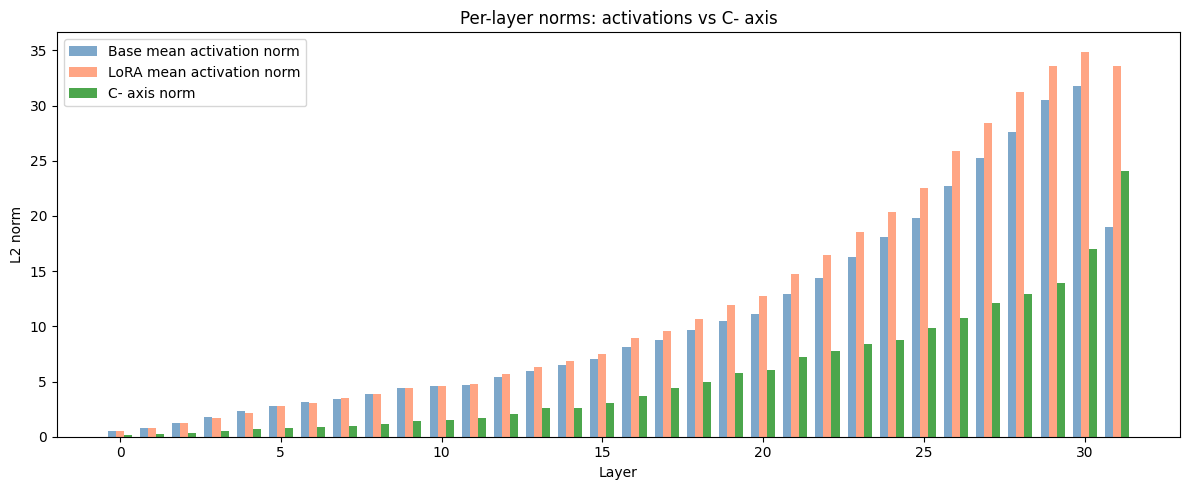

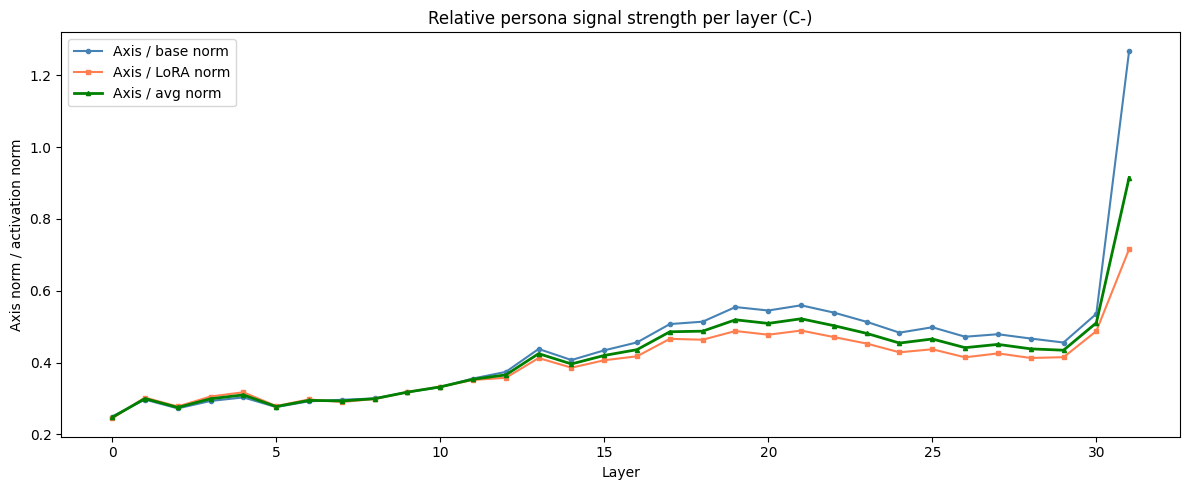

In [13]:
# Per-layer norms and relative signal strength
axis_norms = axis.norm(dim=1).numpy()
base_mean_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
lora_mean_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
avg_mean_norms = (base_mean_norms + lora_mean_norms) / 2

# Relative: how large is the persona axis compared to the activations at each layer?
axis_over_base = axis_norms / (base_mean_norms + 1e-8)
axis_over_lora = axis_norms / (lora_mean_norms + 1e-8)
axis_over_avg = axis_norms / (avg_mean_norms + 1e-8)

# --- Plot 1: Raw norms ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(axis_norms))
width = 0.25
ax.bar(x - width, base_mean_norms, width, label="Base mean activation norm", color="steelblue", alpha=0.7)
ax.bar(x, lora_mean_norms, width, label="LoRA mean activation norm", color="coral", alpha=0.7)
ax.bar(x + width, axis_norms, width, label="C- axis norm", color="green", alpha=0.7)
ax.set_xlabel("Layer")
ax.set_ylabel("L2 norm")
ax.set_title("Per-layer norms: activations vs C- axis")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
plt.show()

# --- Plot 2: Norm ratios (axis / activation norm) ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, axis_over_base, marker="o", markersize=3, label="Axis / base norm", color="steelblue")
ax.plot(x, axis_over_lora, marker="s", markersize=3, label="Axis / LoRA norm", color="coral")
ax.plot(x, axis_over_avg, marker="^", markersize=3, label="Axis / avg norm", color="green", linewidth=2)
ax.set_xlabel("Layer")
ax.set_ylabel("Axis norm / activation norm")
ax.set_title("Relative persona signal strength per layer (C-)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
plt.show()


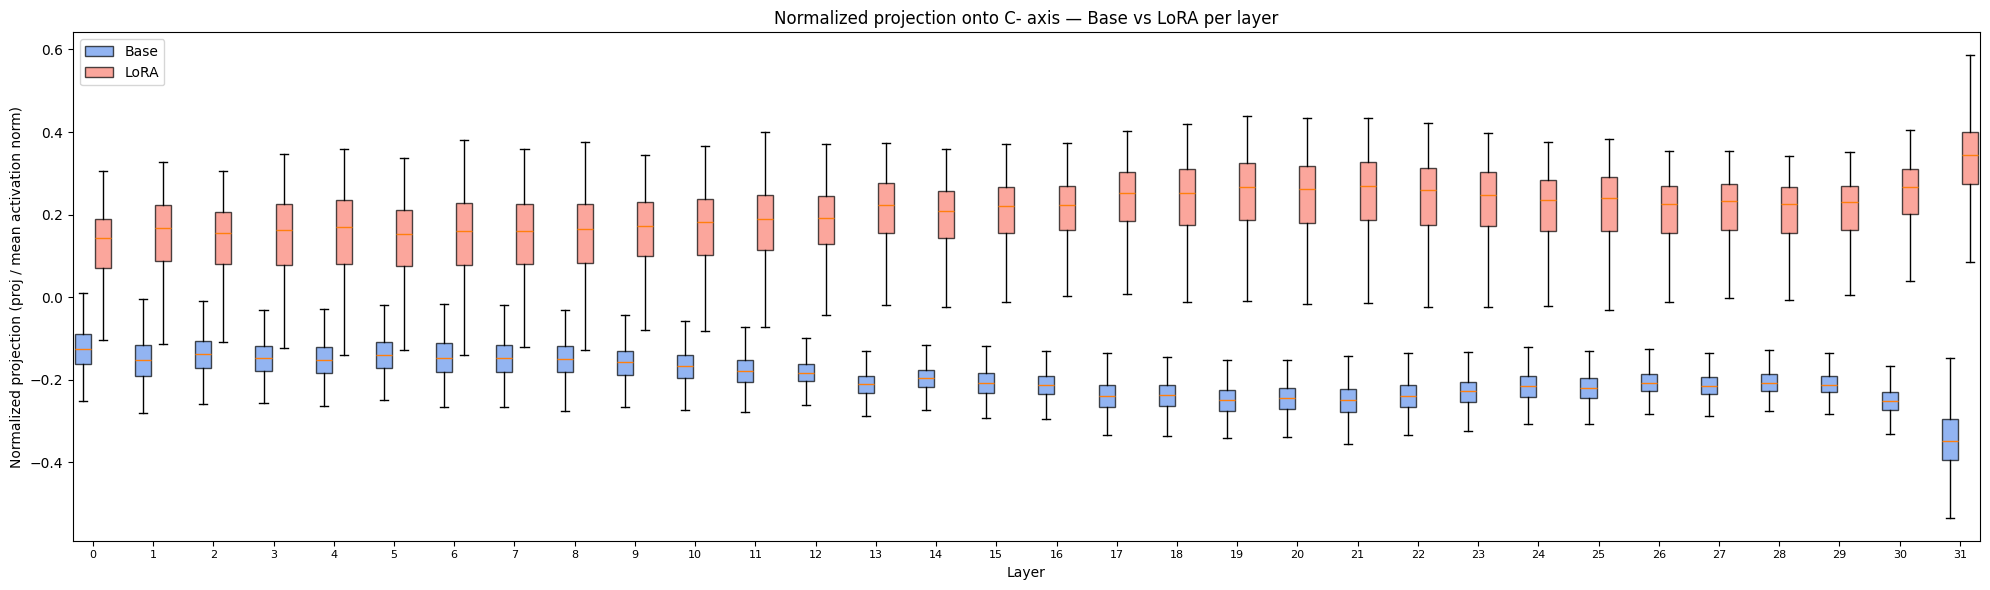

In [14]:
# Project activations onto the axis at the best layer — do the groups separate?
def project_batch(activations: torch.Tensor, axis: torch.Tensor, layer: int) -> np.ndarray:
    """Project batch of activations onto the axis at a given layer."""
    acts = activations[:, layer, :].float()
    ax = axis[layer].float()
    ax_normed = ax / (ax.norm() + 1e-8)
    return (acts @ ax_normed).numpy()


# Normalized projection box plots across all layers
n_layers = axis.shape[0]

base_projs = []
lora_projs = []
for layer_idx in range(n_layers):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)

    # Normalize by average activation norm for that layer & group
    base_norms = base_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)
    lora_norms = lora_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)

    base_projs_raw = proj_base / base_norms.mean().item()
    lora_projs_raw = proj_lora / lora_norms.mean().item()

    center = (base_projs_raw.mean() + lora_projs_raw.mean()) / 2
    base_projs.append(base_projs_raw - center)
    lora_projs.append(lora_projs_raw - center)


# Build side-by-side box plot
positions_base = np.arange(n_layers) * 3
positions_lora = positions_base + 1

fig, ax = plt.subplots(figsize=(20, 6))

bp_base = ax.boxplot(base_projs, positions=positions_base, widths=0.8,
                      patch_artist=True, showfliers=False)
bp_lora = ax.boxplot(lora_projs, positions=positions_lora, widths=0.8,
                      patch_artist=True, showfliers=False)

for patch in bp_base["boxes"]:
    patch.set_facecolor("cornflowerblue")
    patch.set_alpha(0.7)
for patch in bp_lora["boxes"]:
    patch.set_facecolor("salmon")
    patch.set_alpha(0.7)

ax.set_xticks(positions_base + 0.5)
ax.set_xticklabels([str(i) for i in range(n_layers)], fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized projection (proj / mean activation norm)")
ax.set_title("Normalized projection onto C- axis — Base vs LoRA per layer")
ax.legend([bp_base["boxes"][0], bp_lora["boxes"][0]], ["Base", "LoRA"], loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_boxplots_per_layer.png", dpi=150)
plt.show()


*(The t_avoiding template had a per-layer projection-vs-`t_density` correlation plot here. It is omitted because there is no behavioral metric for conscientiousness yet — that analysis will live in notebook 2 once the LLM judge is ready.)*


## 7. Capping layer selection (data-driven)

Pick layers where both the axis norm and Cohen's d are strong. Print a summary table and recommend a contiguous window.

In [15]:
# Compute Cohen's d for projection separation at each layer
axis_norms = axis.norm(dim=1).numpy()
cohens_d = np.zeros(len(axis_norms))

for layer_idx in range(len(axis_norms)):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    mean_diff = proj_base.mean() - proj_lora.mean()
    pooled_std = np.sqrt((proj_base.std()**2 + proj_lora.std()**2) / 2)
    cohens_d[layer_idx] = mean_diff / pooled_std if pooled_std > 0 else 0.0

# Summary table: all layers
print(f"{'Layer':>5}  {'Axis Norm':>10}  {'Cohen d':>8}  {'Norm rank':>9}  {'d rank':>6}")
print("-" * 52)

norm_ranks = np.argsort(np.argsort(-axis_norms))
d_ranks = np.argsort(np.argsort(-cohens_d))

for layer in range(len(axis_norms)):
    marker = " *" if norm_ranks[layer] < 8 and d_ranks[layer] < 8 else ""
    print(f"{layer:>5}  {axis_norms[layer]:>10.4f}  {cohens_d[layer]:>8.3f}  {norm_ranks[layer]+1:>9}  {d_ranks[layer]+1:>6}{marker}")

# Find best contiguous window of ~8 layers by sum of Cohen's d
window_size = 15
best_window_start = 0
best_window_score = -np.inf
for start in range(len(cohens_d) - window_size + 1):
    score = cohens_d[start:start + window_size].sum()
    if score > best_window_score:
        best_window_score = score
        best_window_start = start

capping_layers = list(range(best_window_start, best_window_start + window_size))
best_sep_layer = int(np.argmax(cohens_d))

print(f"\nBest layer by separation (Cohen's d): {best_sep_layer} (d={cohens_d[best_sep_layer]:.3f})")
print(f"\nRecommended capping layers (best contiguous window of {window_size} by sum Cohen's d):")
print(f"  Layers {capping_layers[0]}–{capping_layers[-1]}")
print(f"  Sum Cohen's d: {best_window_score:.2f}")
print(f"  Mean Cohen's d: {best_window_score / window_size:.2f}")


Layer   Axis Norm   Cohen d  Norm rank  d rank
----------------------------------------------------
    0      0.1248    -3.287         32       1
    1      0.2298    -3.690         31       4
    2      0.3394    -3.725         30       6
    3      0.5231    -3.798         29       9
    4      0.6953    -3.757         28       8
    5      0.7682    -3.696         27       5
    6      0.9122    -3.539         26       2
    7      1.0097    -3.659         25       3
    8      1.1536    -3.746         24       7
    9      1.4080    -4.398         23      10
   10      1.5277    -4.495         22      11
   11      1.6788    -4.792         21      12
   12      2.0307    -5.707         20      13
   13      2.5941    -6.457         19      24
   14      2.6365    -6.282         18      20
   15      3.0510    -6.371         17      22
   16      3.7171    -6.937         16      29
   17      4.4578    -6.927         15      28
   18      4.9626    -6.325         14      21
   19  

## 8. Save the axis

In [16]:
torch.save(
    {
        "axis": axis,
        "metadata": {
            "model": MODEL_NAME,
            "lora_hf_dataset_repo": LORA_HF_DATASET_REPO,
            "lora_path_in_repo": LORA_PATH_IN_REPO,
            "persona": PERSONA_SLUG,
            "n_samples": base_stack.shape[0],
            "best_layer_by_separation": best_sep_layer,
            "recommended_capping_layers": capping_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / f"{PERSONA_SLUG}_axis.pt",
)
print(f"Saved axis to {OUTPUT_DIR / f'{PERSONA_SLUG}_axis.pt'}")
print(f"Axis shape: {axis.shape}")
print(f"Best layer (separation): {best_sep_layer}")
print(f"Recommended capping layers: {capping_layers[0]}–{capping_layers[-1]}")


Saved axis to /root/persona-shattering-lasr/scratch/llama_8b_instruct/activation_capping/c_minus/c_minus_axis.pt
Axis shape: torch.Size([32, 4096])
Best layer (separation): 0
Recommended capping layers: 0–14


## 8b. Compute and save per-layer projection ranges

Compute `(min, max)` of projections along the axis for **all layers**, across both base and LoRA samples. This is used by `ActivationCappedModel` to set capping thresholds.

In [17]:
def compute_per_layer_range(
    base_activations: torch.Tensor,
    lora_activations: torch.Tensor,
    axis: torch.Tensor,
    layers: list[int],
) -> dict[int, tuple[float, float]]:
    """Compute (global_min, global_max) of projections per layer across both distributions.

    Args:
        base_activations: (N, n_layers, hidden_dim) base model activations.
        lora_activations: (N, n_layers, hidden_dim) LoRA model activations.
        axis: (n_layers, hidden_dim) direction axis.
        layers: Layer indices to compute ranges for.

    Returns:
        {layer_idx: (min_projection, max_projection)}
    """
    ranges = {}
    for layer_idx in layers:
        ax = axis[layer_idx].float()
        ax_normed = ax / (ax.norm() + 1e-8)

        base_proj = (base_activations[:, layer_idx, :].float() @ ax_normed).numpy()
        lora_proj = (lora_activations[:, layer_idx, :].float() @ ax_normed).numpy()

        global_min = float(min(base_proj.min(), lora_proj.min()))
        global_max = float(max(base_proj.max(), lora_proj.max()))
        ranges[layer_idx] = (global_min, global_max)

    return ranges


# Compute for all layers
all_layers = list(range(axis.shape[0]))
per_layer_range = compute_per_layer_range(base_stack, lora_stack, axis, all_layers)

# Save
torch.save(
    {
        "per_layer_range": per_layer_range,
        "metadata": {
            "model": MODEL_NAME,
            "lora_hf_dataset_repo": LORA_HF_DATASET_REPO,
            "lora_path_in_repo": LORA_PATH_IN_REPO,
            "persona": PERSONA_SLUG,
            "n_samples": base_stack.shape[0],
            "layers": all_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / f"{PERSONA_SLUG}_per_layer_range.pt",
)

# Print summary
print(f"Saved per-layer range to {OUTPUT_DIR / f'{PERSONA_SLUG}_per_layer_range.pt'}")
print(f"\n{'Layer':>5}  {'Min':>10}  {'Max':>10}  {'Range':>10}")
print("-" * 40)
for layer in all_layers:
    lo, hi = per_layer_range[layer]
    print(f"{layer:>5}  {lo:>10.2f}  {hi:>10.2f}  {hi - lo:>10.2f}")


Saved per-layer range to /root/persona-shattering-lasr/scratch/llama_8b_instruct/activation_capping/c_minus/c_minus_per_layer_range.pt

Layer         Min         Max       Range
----------------------------------------
    0       -0.11        0.17        0.28
    1       -0.31        0.16        0.47
    2       -0.49        0.21        0.70
    3       -0.83        0.26        1.09
    4       -1.09        0.32        1.41
    5       -0.99        0.64        1.62
    6       -1.27        0.74        2.01
    7       -1.00        1.16        2.16
    8       -1.32        1.18        2.51
    9       -1.48        1.21        2.70
   10       -1.66        1.28        2.94
   11       -1.55        1.67        3.22
   12       -1.18        2.41        3.59
   13       -1.30        2.84        4.14
   14       -1.31        3.00        4.30
   15       -1.33        3.64        4.98
   16       -1.18        4.67        5.85
   17       -1.91        4.98        6.89
   18       -1.90        

## Appendix: Upload to monorepo

Upload axis, per-layer ranges, raw activations, a snapshot of this notebook, and a `run_info.json` provenance file to `persona-shattering-lasr/monorepo` under `activation_capping/{persona}/`.


In [18]:
import datetime
import shutil
import subprocess

from huggingface_hub import HfApi


def _git(*args: str) -> str | None:
    try:
        return subprocess.check_output(["git", *args], cwd=str(REPO_ROOT), text=True).strip()
    except Exception:
        return None


def _git_dirty() -> bool | None:
    out = _git("status", "--porcelain")
    if out is None:
        return None
    return bool(out)


# Stage everything we want to upload into a clean directory
upload_staging = OUTPUT_DIR / "monorepo_upload"
if upload_staging.exists():
    shutil.rmtree(upload_staging)
upload_staging.mkdir(parents=True)

artifacts = [
    OUTPUT_DIR / f"{PERSONA_SLUG}_axis.pt",
    OUTPUT_DIR / f"{PERSONA_SLUG}_per_layer_range.pt",
    OUTPUT_DIR / f"{PERSONA_SLUG}_activations.pt",
    OUTPUT_DIR / "axis_norms_per_layer.png",
    OUTPUT_DIR / "relative_axis_norms.png",
    OUTPUT_DIR / "projection_boxplots_per_layer.png",
]
for p in artifacts:
    if p.exists():
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"  staging {p.name} ({size_mb:.1f} MB)")
        shutil.copy2(p, upload_staging / p.name)
    else:
        print(f"  SKIP (missing): {p.name}")

# Snapshot of this notebook (copied verbatim from disk)
notebook_rel_path = "scripts_dev/activation_capping/ocean/1. c_minus_activation_axis.ipynb"
notebook_abs_path = REPO_ROOT / notebook_rel_path
if notebook_abs_path.exists():
    shutil.copy2(notebook_abs_path, upload_staging / "notebook_snapshot.ipynb")
    print(f"  staging notebook_snapshot.ipynb")
else:
    print(f"  WARNING: notebook file not found at {notebook_abs_path} — snapshot not uploaded")

# Provenance: run_info.json
git_commit = _git("rev-parse", "HEAD")
git_branch = _git("rev-parse", "--abbrev-ref", "HEAD")
git_dirty = _git_dirty()
if git_dirty:
    print("  WARNING: uploading from a DIRTY working tree — uncommitted changes will not be reflected in git_commit.")

run_info = {
    "persona": PERSONA_SLUG,
    "base_model": MODEL_NAME,
    "lora": {
        "hf_dataset_repo": LORA_HF_DATASET_REPO,
        "path_in_repo": LORA_PATH_IN_REPO,
    },
    "dataset": str(DATASET_PATH.relative_to(REPO_ROOT)) if DATASET_PATH.is_absolute() else str(DATASET_PATH),
    "n_samples": int(base_stack.shape[0]),
    "num_rollouts": NUM_ROLLOUTS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "batch_size": BATCH_SIZE,
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "seed": SEED,
    "best_layer_by_separation": int(best_sep_layer),
    "capping_layers_recommended": list(map(int, capping_layers)),
    "git": {
        "commit": git_commit,
        "branch": git_branch,
        "dirty": git_dirty,
    },
    "notebook_path": notebook_rel_path,
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
}
with open(upload_staging / "run_info.json", "w") as f:
    json.dump(run_info, f, indent=2, default=str)
print(f"  staged run_info.json")

# Upload
api = HfApi()
api.upload_folder(
    folder_path=str(upload_staging),
    repo_id=MONOREPO_ID,
    repo_type="dataset",
    path_in_repo=MONOREPO_UPLOAD_PATH,
    commit_message=f"activation_capping: add {PERSONA_SLUG} axis + per-layer ranges",
)
print(f"\nUploaded to https://huggingface.co/datasets/{MONOREPO_ID}/tree/main/{MONOREPO_UPLOAD_PATH}")

  staging c_minus_axis.pt (0.5 MB)
  staging c_minus_per_layer_range.pt (0.0 MB)
  staging c_minus_activations.pt (361.3 MB)
  staging axis_norms_per_layer.png (0.0 MB)
  staging relative_axis_norms.png (0.1 MB)
  staging projection_boxplots_per_layer.png (0.1 MB)
  staging notebook_snapshot.ipynb
  staged run_info.json


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 1):   0%|          |  203kB /  380MB,   ???B/s  

Processing Files (0 / 1):   4%|▍         | 16.3MB /  380MB, 80.5MB/s  

...

Processing Files (6 / 6): 100%|██████████|  380MB /  380MB,  146MB/s  

New Data Upload: 100%|██████████|  379MB /  379MB,  146MB/s  

Processing Files (6 / 6): 100%|██████████|  380MB /  380MB, 47.4MB/s  


New Data Upload: 100%|██████████|  379MB /  379MB, 47.4MB/s  


Uploaded to https://huggingface.co/datasets/persona-shattering-lasr/monorepo/tree/main/activation_capping/c_minus
